# Predicción de costos médicos individuales con Regresión Lineal Múltiple

## 1. Introducción y enfoque ejecutivo

**Problema de negocio:** una aseguradora de gastos médicos necesita estimar el **costo médico anual esperado**
de un asegurado (`charges`) a partir de sus características personales (edad, sexo, índice de masa corporal,
número de hijos, hábito de fumar y región de residencia).

**Objetivo analítico:** construir un modelo predictivo de **regresión** que permita anticipar el costo médico
de un cliente nuevo o potencial, y cuantificar qué variables influyen más en ese costo.

**Decisión que pueden tomar los directivos con este modelo:**
- Ajustar las **primas de seguro** de forma más precisa según el perfil de riesgo del cliente (en particular,
  el hábito de fumar, que se anticipa como el factor más determinante).
- Identificar **segmentos de alto costo esperado** (p. ej. fumadores con IMC elevado) para diseñar políticas
  de prevención o recargos diferenciados.
- Simular el costo esperado de **clientes nuevos** antes de emitir una póliza, apoyando la suscripción
  (underwriting) con evidencia cuantitativa en lugar de reglas fijas.

Este es un problema de **aprendizaje supervisado de regresión**: la variable objetivo (`charges`) es numérica
continua, y se cuenta con datos históricos etiquetados (costo real ya observado) para entrenar el modelo.


## 2. Explicación del algoritmo: Regresión Lineal Múltiple

**¿Qué es?** La Regresión Lineal es un algoritmo de **aprendizaje supervisado** para problemas de
**regresión** (predicción de una variable numérica continua). Es supervisado porque durante el entrenamiento
el modelo recibe pares (X, y) — características del asegurado y su costo real — y aprende los coeficientes
que minimizan el error entre el costo predicho y el costo real.

**¿Cómo funciona?** El modelo asume una relación lineal entre las variables predictoras y la variable
objetivo:

`charges ≈ b0 + b1*age + b2*bmi + b3*children + b4*sex + b5*smoker + b6*region...`

Los coeficientes (`b1`, `b2`, ...) se estiman minimizando la suma de errores cuadráticos (mínimos cuadrados
ordinarios) entre los valores predichos y los valores reales de `charges` en el conjunto de entrenamiento.

**¿Por qué es una buena primera opción para este problema?**
- Es **interpretable**: cada coeficiente indica cuánto cambia el costo esperado por unidad de la variable
  (muy útil para explicarle a un directivo *por qué* el modelo predice un costo alto).
- Sirve como **línea base** sólida antes de probar modelos más complejos.
- Es rápido de entrenar y no requiere grandes volúmenes de datos.

**Limitación a considerar:** asume relaciones lineales; si existen interacciones fuertes (p. ej. el efecto
del `bmi` sobre el costo es mucho mayor en fumadores que en no fumadores), el modelo lineal simple puede no
capturarlas del todo. Esto se revisa en la sección de evaluación y conclusiones.


## 3. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 4. Obtención de datos y carga

**Fuente de los datos:** dataset público **Medical Cost Personal Dataset** (costos médicos individuales de
EE. UU.), ampliamente utilizado en ciencia de datos para practicar regresión. Contiene **1,338 registros**
de asegurados con las siguientes columnas:

| Variable | Descripción |
|---|---|
| `age` | Edad del asegurado (años) |
| `sex` | Sexo biológico (`male`/`female`) |
| `bmi` | Índice de masa corporal |
| `children` | Número de hijos/dependientes cubiertos por el seguro |
| `smoker` | Si la persona fuma (`yes`/`no`) |
| `region` | Región de residencia en EE. UU. (`northeast`, `northwest`, `southeast`, `southwest`) |
| `charges` | **Variable objetivo**: costo médico individual facturado por el seguro (USD) |

Se carga directamente desde un repositorio público en GitHub para asegurar reproducibilidad del pipeline.


In [2]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
dfSeguro = pd.read_csv(url)
dfSeguro.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Exploración inicial del conjunto de datos

In [3]:
dfSeguro.shape

(1338, 7)

In [4]:
dfSeguro.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [5]:
dfSeguro.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
dfSeguro.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Revisión de valores nulos
dfSeguro.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No hay valores nulos en ninguna columna, por lo que no será necesario imputar datos faltantes. Las
variables `sex`, `smoker` y `region` son categóricas de tipo texto y deberán codificarse antes de entrenar
el modelo.


## 5. Análisis exploratorio de datos (EDA)

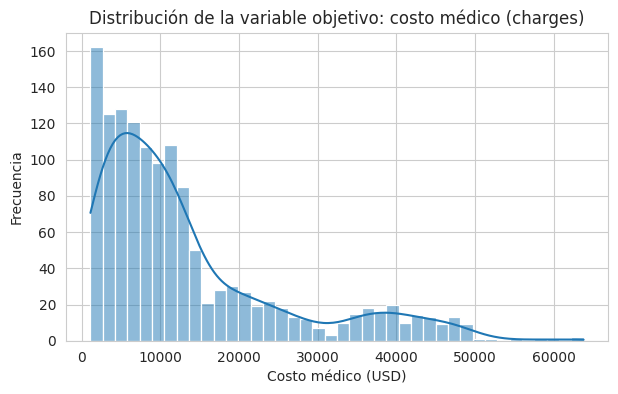

In [8]:
plt.figure(figsize=(7,4))
sns.histplot(dfSeguro["charges"], bins=40, kde=True, color="#1f77b4")
plt.title("Distribución de la variable objetivo: costo médico (charges)")
plt.xlabel("Costo médico (USD)")
plt.ylabel("Frecuencia")
plt.show()


**Hallazgo:** la distribución de `charges` está fuertemente sesgada a la derecha: la mayoría de los
asegurados tiene costos bajos (menos de 15,000 USD), pero existe una cola de casos con costos muy altos
(hasta más de 60,000 USD). Esto sugiere que un subgrupo específico de la población concentra los costos
más elevados — se investiga a continuación si ese subgrupo corresponde a los fumadores.


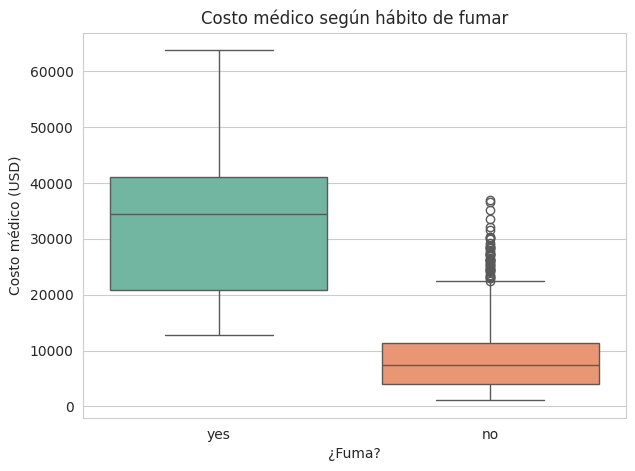

In [9]:
plt.figure(figsize=(7,5))
sns.boxplot(data=dfSeguro, x="smoker", y="charges", hue="smoker", palette="Set2", legend=False)
plt.title("Costo médico según hábito de fumar")
plt.xlabel("¿Fuma?")
plt.ylabel("Costo médico (USD)")
plt.show()


**Hallazgo clave:** los fumadores presentan costos médicos notablemente más altos y con mayor
dispersión que los no fumadores. Esta variable se perfila como la más determinante del modelo.


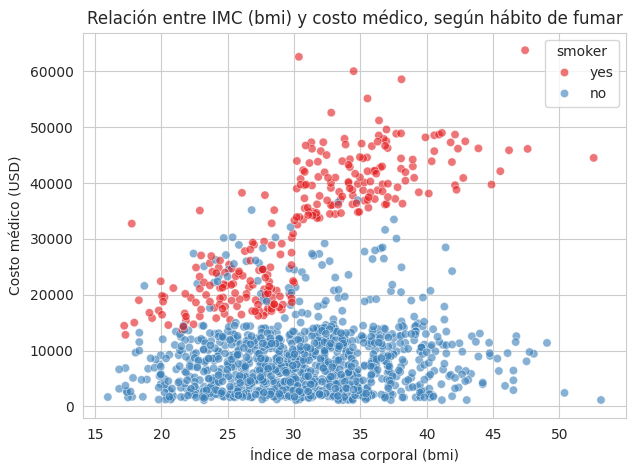

In [10]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=dfSeguro, x="bmi", y="charges", hue="smoker", palette="Set1", alpha=0.6)
plt.title("Relación entre IMC (bmi) y costo médico, según hábito de fumar")
plt.xlabel("Índice de masa corporal (bmi)")
plt.ylabel("Costo médico (USD)")
plt.show()


**Hallazgo:** en no fumadores, el `bmi` tiene poca relación visible con el costo. En fumadores, un
`bmi` alto se asocia con costos considerablemente mayores — es decir, existe una **interacción** entre
`bmi` y `smoker` que un modelo puramente lineal captura solo de forma parcial (se retoma en conclusiones).


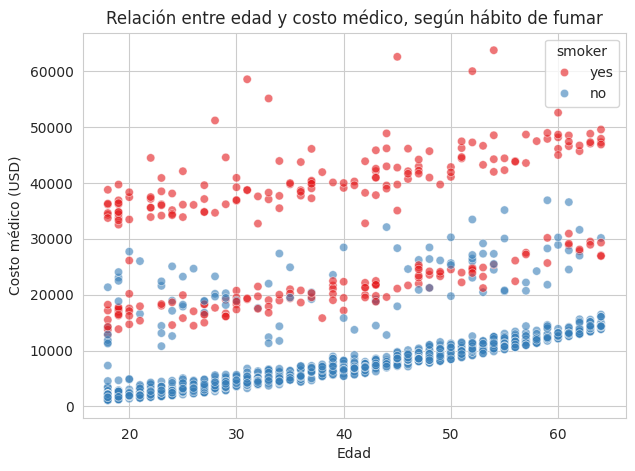

In [11]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=dfSeguro, x="age", y="charges", hue="smoker", palette="Set1", alpha=0.6)
plt.title("Relación entre edad y costo médico, según hábito de fumar")
plt.xlabel("Edad")
plt.ylabel("Costo médico (USD)")
plt.show()


**Hallazgo:** dentro de cada grupo (fumador / no fumador) se observa una tendencia creciente y
razonablemente lineal entre edad y costo, consistente con el supuesto del modelo de regresión lineal.


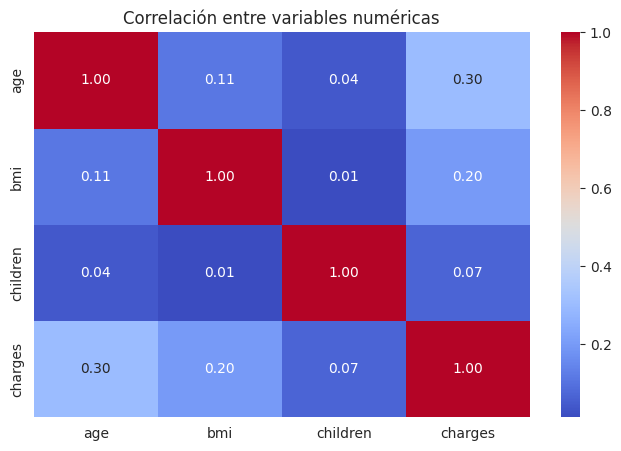

In [12]:
plt.figure(figsize=(8,5))
sns.heatmap(dfSeguro[["age","bmi","children","charges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()


**Hallazgo:** `age` tiene la correlación lineal más fuerte con `charges` entre las variables numéricas
(≈0.30), seguida de `bmi`. `children` muestra una correlación muy débil. Esto es consistente con lo
observado en los gráficos anteriores: la variable categórica `smoker` (no incluida en esta matriz numérica)
se perfila como el factor más influyente, y se confirmará con los coeficientes del modelo.


## 6. Preprocesamiento

Se codifican las variables categóricas antes de entrenar el modelo:
- `sex`: binaria (`male`/`female`) → se codifica como 0/1 con `map`.
- `smoker`: binaria (`yes`/`no`) → se codifica como 0/1 con `map`.
- `region`: tiene 4 categorías sin orden natural → se codifica con **one-hot encoding**
  (`pd.get_dummies`, eliminando una categoría de referencia con `drop_first=True` para evitar
  multicolinealidad perfecta entre las columnas dummy).


## 7. Identificar variables predictoras y variable objetivo

In [13]:
# Variable objetivo
y = dfSeguro["charges"]

# Variables predictoras (antes de codificar)
X_crudo = dfSeguro.drop(columns=["charges"])

print("Variables predictoras (antes de codificar):")
print(X_crudo.columns.tolist())
print("Variable objetivo:", y.name)


Variables predictoras (antes de codificar):
['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Variable objetivo: charges


## 8. División de los datos: entrenamiento y prueba

Se utiliza una división **80% entrenamiento / 20% prueba**, estándar razonable para este tamaño de dataset
(1,338 registros). Se fija `random_state=42` para que la división sea reproducible.

**Prevención de fuga de información (data leakage):** el `scaler` que se ajusta más adelante se calcula
**únicamente con `X_train`**; el conjunto de prueba solo se **transforma** con esos parámetros, nunca se
usa para ajustar nada.


In [14]:
X_train_crudo, X_test_crudo, y_train, y_test = train_test_split(
    X_crudo, y, test_size=0.20, random_state=42
)

print("X_train", X_train_crudo.shape)
print("X_test", X_test_crudo.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)


X_train (1070, 6)
X_test (268, 6)
y_train (1070,)
y_test (268,)


## Codificación de variables categóricas

In [15]:
# Copiamos los conjuntos para no modificar los originales
X_train = X_train_crudo.copy()
X_test = X_test_crudo.copy()

# --- Codificación binaria ---
X_train["sex"] = X_train["sex"].map({"male": 1, "female": 0})
X_test["sex"] = X_test["sex"].map({"male": 1, "female": 0})

X_train["smoker"] = X_train["smoker"].map({"yes": 1, "no": 0})
X_test["smoker"] = X_test["smoker"].map({"yes": 1, "no": 0})

# --- One-hot encoding de region (ajustado sobre train, aplicado igual a test) ---
X_train = pd.get_dummies(X_train, columns=["region"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["region"], drop_first=True)

# Aseguramos que test tenga exactamente las mismas columnas que train (incluso si faltara alguna categoría)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.head()


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
560,46,0,19.95,2,0,True,False,False
1285,47,0,24.32,0,0,False,False,False
1142,52,0,24.86,0,0,False,True,False
969,39,0,34.32,5,0,False,True,False
486,54,0,21.47,3,0,True,False,False


## Escalado de variables

Se utiliza `StandardScaler` (media 0, desviación estándar 1). Aunque la Regresión Lineal no lo requiere
estrictamente para su desempeño predictivo, escalar ayuda a que los coeficientes sean **comparables entre
sí** en magnitud, facilitando la interpretación de importancia de variables.


In [16]:
scaler = StandardScaler()

# Ajustamos el scaler SOLO con el conjunto de entrenamiento
X_train_escalado = scaler.fit_transform(X_train)
# El conjunto de prueba solo se transforma (no se vuelve a ajustar)
X_test_escalado = scaler.transform(X_test)

print("Columnas finales del modelo:", X_train.columns.tolist())


Columnas finales del modelo: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


## 9. Implementación del modelo: Regresión Lineal Múltiple

Se utiliza `LinearRegression` de scikit-learn con sus parámetros por defecto (mínimos cuadrados ordinarios,
sin regularización), adecuado dado que el número de variables (8) es pequeño frente al número de
observaciones (1,338), por lo que el riesgo de sobreajuste por exceso de variables es bajo.


In [17]:
modelo = LinearRegression()
modelo.fit(X_train_escalado, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Importancia de las variables (coeficientes del modelo)

In [18]:
coeficientes = pd.DataFrame({
    "variable": X_train.columns,
    "coeficiente": modelo.coef_
})
coeficientes["coeficiente_abs"] = coeficientes["coeficiente"].abs()
coeficientes = coeficientes.sort_values("coeficiente_abs", ascending=False)
coeficientes


,variable,coeficiente,coeficiente_abs
4,smoker,9558.481409,9558.481409
0,age,3614.975415,3614.975415
2,bmi,2036.228123,2036.228123
3,children,516.890247,516.890247
7,region_southwest,-349.110678,349.110678
6,region_southeast,-290.157047,290.157047
5,region_northwest,-158.140981,158.140981
1,sex,-9.293101,9.293101


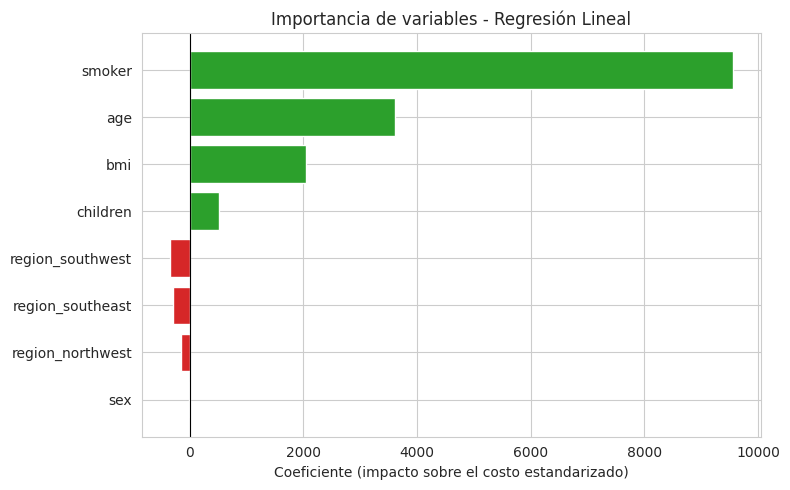

In [19]:
orden = coeficientes.sort_values("coeficiente_abs")

colores = ["#d62728" if c < 0 else "#2ca02c" for c in orden["coeficiente"]]

plt.figure(figsize=(8,5))
plt.barh(orden["variable"], orden["coeficiente"], color=colores)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (impacto sobre el costo estandarizado)")
plt.title("Importancia de variables - Regresión Lineal")
plt.tight_layout()
plt.show()


**Interpretación:** como se anticipaba en el EDA, `smoker` tiene, por amplio margen, el coeficiente
positivo más grande: fumar es el factor que más incrementa el costo médico esperado. Le siguen `age` y
`bmi`, ambos con efecto positivo. `sex` y `region` tienen coeficientes pequeños, es decir, aportan poco al
costo una vez controlado por las demás variables. Esta información es directamente útil para el negocio:
confirma que la política de precios debería diferenciar principalmente por **hábito de fumar, edad e IMC**.


## Predicciones sobre el conjunto de prueba

In [20]:
prediccion = modelo.predict(X_test_escalado)


In [21]:
comparacion = pd.DataFrame({
    "costo real": y_test.values.round(2),
    "costo predicho": prediccion.round(2),
    "diferencia": (y_test.values - prediccion).round(2)
})
comparacion.head(15)


,costo real,costo predicho,diferencia
0,9095.07,8969.55,125.52
1,5272.18,7068.75,-1796.57
2,29330.98,36858.41,-7527.43
3,9301.89,9454.68,-152.78
4,33750.29,26973.17,6777.12
5,4536.26,10864.11,-6327.85
6,2117.34,170.28,1947.06
7,14210.54,16903.45,-2692.91
8,3732.63,1092.43,2640.19
9,10264.44,11218.34,-953.90


## 10. Evaluación del modelo

Al tratarse de un problema de **regresión**, se usan métricas de error continuo: **MAE** (error absoluto
medio), **RMSE** (raíz del error cuadrático medio) y **R²** (proporción de varianza explicada).


In [22]:
mae = mean_absolute_error(y_test, prediccion)
rmse = np.sqrt(mean_squared_error(y_test, prediccion))
r2 = r2_score(y_test, prediccion)

print(f"MAE  (error absoluto medio):        {mae:,.2f} USD")
print(f"RMSE (raíz del error cuadrático):    {rmse:,.2f} USD")
print(f"R2   (varianza explicada):           {r2:.4f}")


MAE  (error absoluto medio):        4,181.19 USD
RMSE (raíz del error cuadrático):    5,796.28 USD
R2   (varianza explicada):           0.7836


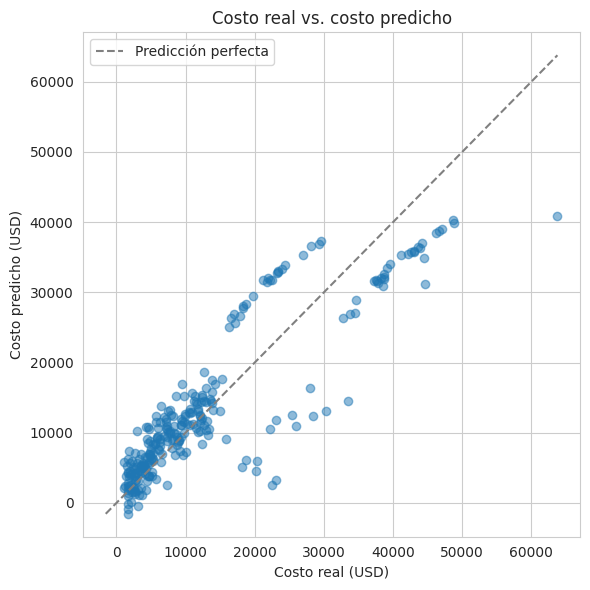

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, prediccion, alpha=0.5, color="#1f77b4")
lims = [min(y_test.min(), prediccion.min()), max(y_test.max(), prediccion.max())]
plt.plot(lims, lims, linestyle="--", color="gray", label="Predicción perfecta")
plt.xlabel("Costo real (USD)")
plt.ylabel("Costo predicho (USD)")
plt.title("Costo real vs. costo predicho")
plt.legend()
plt.tight_layout()
plt.show()


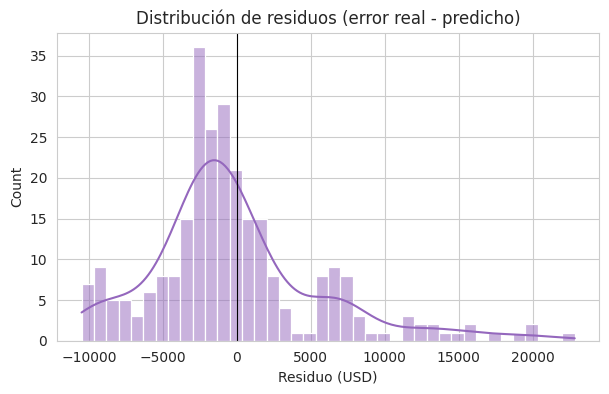

In [24]:
residuos = y_test.values - prediccion
plt.figure(figsize=(7,4))
sns.histplot(residuos, bins=40, kde=True, color="#9467bd")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Distribución de residuos (error real - predicho)")
plt.xlabel("Residuo (USD)")
plt.show()


**Interpretación de las métricas en el contexto del problema:**
- **MAE:** en promedio, la predicción del modelo se desvía del costo real por el monto reportado arriba —
  una referencia directa del error esperado en USD al cotizar una póliza.
- **RMSE:** al elevar al cuadrado los errores, penaliza más los casos donde el modelo falla por mucho; que
  sea mayor al MAE confirma que existen algunos casos (probablemente fumadores con IMC alto) donde el error
  es más grande, tal como se observó en el EDA.
- **R²:** el modelo explica una proporción relevante de la variabilidad del costo médico, aunque no toda —
  consistente con la interacción `bmi × smoker` detectada en el EDA, que un modelo lineal simple no captura
  del todo. Esto se documenta como limitación y oportunidad de mejora en las conclusiones.


## 11. Implementación con datos nuevos

Se simulan dos clientes nuevos (que no forman parte de `train` ni de `test`), con las mismas columnas que
`X`. Se aplica el **mismo preprocesamiento** ya ajustado (misma codificación y `scaler.transform`, sin
volver a ajustar nada), tal como se haría al cotizar una póliza real.


In [25]:
# Cliente 1: joven, no fumador, IMC normal
# Cliente 2: adulto mayor, fumador, IMC alto
clientes_nuevos = pd.DataFrame([
    {"age": 24, "sex": "female", "bmi": 22.5, "children": 0, "smoker": "no",  "region": "northeast"},
    {"age": 55, "sex": "male",   "bmi": 34.0, "children": 2, "smoker": "yes", "region": "southeast"},
], index=["cliente_1", "cliente_2"])

clientes_nuevos


,age,sex,bmi,children,smoker,region
cliente_1,24,female,22.5,0,no,northeast
cliente_2,55,male,34.0,2,yes,southeast


In [26]:
# Aplicamos el MISMO preprocesamiento que a train/test (sin volver a ajustar nada)
clientes_prep = clientes_nuevos.copy()

clientes_prep["sex"] = clientes_prep["sex"].map({"male": 1, "female": 0})
clientes_prep["smoker"] = clientes_prep["smoker"].map({"yes": 1, "no": 0})

clientes_prep = pd.get_dummies(clientes_prep, columns=["region"], drop_first=True)
clientes_prep = clientes_prep.reindex(columns=X_train.columns, fill_value=0)

clientes_escalado = scaler.transform(clientes_prep)
prediccion_nueva = modelo.predict(clientes_escalado)

for nombre, costo in zip(clientes_nuevos.index, prediccion_nueva):
    print(f"{nombre}: costo médico anual estimado = {costo:,.2f} USD")


cliente_1: costo médico anual estimado = 1,820.78 USD
cliente_2: costo médico anual estimado = 37,488.82 USD


**Explicación del resultado:** para `cliente_1` (joven, no fumador, IMC normal) el modelo predice un
costo bajo, consistente con el perfil de menor riesgo observado en los datos históricos. Para `cliente_2`
(mayor edad, fumador, IMC alto) el modelo predice un costo considerablemente más alto — combina los tres
factores que el modelo identificó como más influyentes (`smoker`, `age`, `bmi`). Este tipo de estimación es
la que la aseguradora podría usar para **cotizar una prima ajustada al riesgo** antes de emitir la póliza.


## 12. Conclusiones y recomendaciones ejecutivas

**Desempeño del modelo:** la Regresión Lineal Múltiple logra un desempeño razonable prediciendo el costo
médico individual (ver R², MAE y RMSE reportados arriba), usando solo 6 variables fáciles de obtener de un
cliente (edad, sexo, IMC, hijos, hábito de fumar y región).

**Principal hallazgo de negocio:** el **hábito de fumar** es, por amplio margen, el factor que más
incrementa el costo médico esperado, seguido de la **edad** y el **índice de masa corporal**. El sexo y la
región de residencia tienen un impacto marginal.

**Limitación identificada:** existe una interacción entre `bmi` y `smoker` (el IMC eleva mucho más el costo
en fumadores que en no fumadores) que un modelo puramente lineal captura solo de forma parcial. Un modelo
no lineal (p. ej. Random Forest o Gradient Boosting) o la inclusión de un término de interacción
`bmi × smoker` podría mejorar la precisión en ese segmento específico.

**Recomendaciones para la dirección:**
1. **Ajustar la política de primas** dando mayor peso al hábito de fumar, la edad y el IMC del asegurado,
   en línea con lo que el modelo identifica como los factores de mayor impacto en el costo.
2. **Priorizar programas de prevención** (dejar de fumar, control de peso) dirigidos a los segmentos de
   mayor riesgo identificado, ya que son los que generan el costo esperado más alto y con mayor variabilidad.
3. **Usar el modelo como apoyo en la cotización** de nuevas pólizas, complementando — no reemplazando — el
   criterio del equipo de suscripción, dado que el modelo no explica el 100% de la variabilidad del costo.
4. **Evaluar un modelo no lineal** en una siguiente iteración para mejorar la precisión en el segmento de
   fumadores con IMC alto, que es donde el modelo actual presenta mayor error.
